In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "helmholtz_data" 
FILE_PATH = DATA_DIR / "Helmholtz.h5"

In [3]:
import h5py

sample_idx = 0
sample_key = f"Sample_{sample_idx}"

with h5py.File(FILE_PATH, 'r') as f:
    a_sample = jnp.array(f[sample_key]['a'][:])
    bc_sample = f[sample_key]['bc'][()]
    u_sample = jnp.array(f[sample_key]['u'][:])

# Flatten for network
a_flat = a_sample.reshape(-1, 1)
u_flat = u_sample.reshape(-1, 1)

print(f"Extracted Spatial Field 'a' Shape: {a_flat.shape}")
print(f"Extracted Boundary Condition 'bc' Value: {bc_sample:.4f}")
print(f"Extracted Solution 'u' Shape: {u_flat.shape}")

Extracted Spatial Field 'a' Shape: (16384, 1)
Extracted Boundary Condition 'bc' Value: 0.4713
Extracted Solution 'u' Shape: (16384, 1)


E0705 19:53:28.670249    5328 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0705 19:53:28.681041    5227 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [4]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]
bc_val_array = jnp.ones_like(x_bc) * bc_sample

In [5]:
epochs = 1000
M = 512 
hidden_layers = [256, 256, 256, 256] 

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = jnp.sin(h) 
            
        # NEW: Final linear layer to output the prediction directly
        u_pred = nn.Dense(1, use_bias=False)(h)
        return u_pred
    
class ConcatFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)

        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        
        # Start the list with the 1024 RFF features
        all_features = [h_rff] 

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = jnp.sin(h) 
            # Append each of the four 256-feature hidden layers
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
        
        # Final prediction layer sees all 2048 features during training
        u_pred = nn.Dense(1, use_bias=False)(combined_h)
        return u_pred

# Initialize
# model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)
model = ConcatFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [6]:
optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

# VMAP the forward pass
u_pred_vmap = vmap(model.apply, in_axes=(None, 0, 0))

def compute_data_loss(params, x_batch, y_batch, u_batch):
    # Predict u directly from the neural network
    u_pred = u_pred_vmap(params, x_batch, y_batch)
    
    # Calculate pure MSE against the simulation data
    loss = jnp.mean((u_pred - u_batch) ** 2)
    return loss

loss_grad_fn = jax.jit(value_and_grad(compute_data_loss, argnums=0))

@jax.jit
def update_network(params, opt_state, x_batch, y_batch, u_batch):
    loss, grads = loss_grad_fn(params, x_batch, y_batch, u_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [7]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0]
spatial_batch_size = 5000 # Increased batch size for more stable data gradients
loss_history = []

for epoch in tqdm(range(epochs), desc="Pure Data-Loss Sanity Check"):
    rng, shuffle_key = jax.random.split(rng)
    batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)
    
    x_chunk = x[batch_idx]
    y_chunk = y[batch_idx]
    u_chunk = u_flat[batch_idx]
    
    params, opt_state, loss = update_network(
        params, opt_state, x_chunk, y_chunk, u_chunk
    )
    
    loss_history.append(loss)
    
    if epoch % 100 == 0:
        sigma_val = jax.nn.softplus(params['params']['raw_sigma'][0])
        print(f"Epoch {epoch} | Data MSE Loss: {loss:.4e} | Learned Sigma: {sigma_val:.4f}")

Pure Data-Loss Sanity Check:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0 | Data MSE Loss: 1.5032e+00 | Learned Sigma: 3.0495
Epoch 100 | Data MSE Loss: 1.4535e-04 | Learned Sigma: 3.0492
Epoch 200 | Data MSE Loss: 4.9260e-05 | Learned Sigma: 3.0484
Epoch 300 | Data MSE Loss: 2.6682e-05 | Learned Sigma: 3.0479
Epoch 400 | Data MSE Loss: 1.7608e-05 | Learned Sigma: 3.0475
Epoch 500 | Data MSE Loss: 1.2311e-05 | Learned Sigma: 3.0472
Epoch 600 | Data MSE Loss: 9.4119e-06 | Learned Sigma: 3.0469
Epoch 700 | Data MSE Loss: 7.7685e-06 | Learned Sigma: 3.0467
Epoch 800 | Data MSE Loss: 6.0484e-06 | Learned Sigma: 3.0465
Epoch 900 | Data MSE Loss: 5.1259e-06 | Learned Sigma: 3.0463


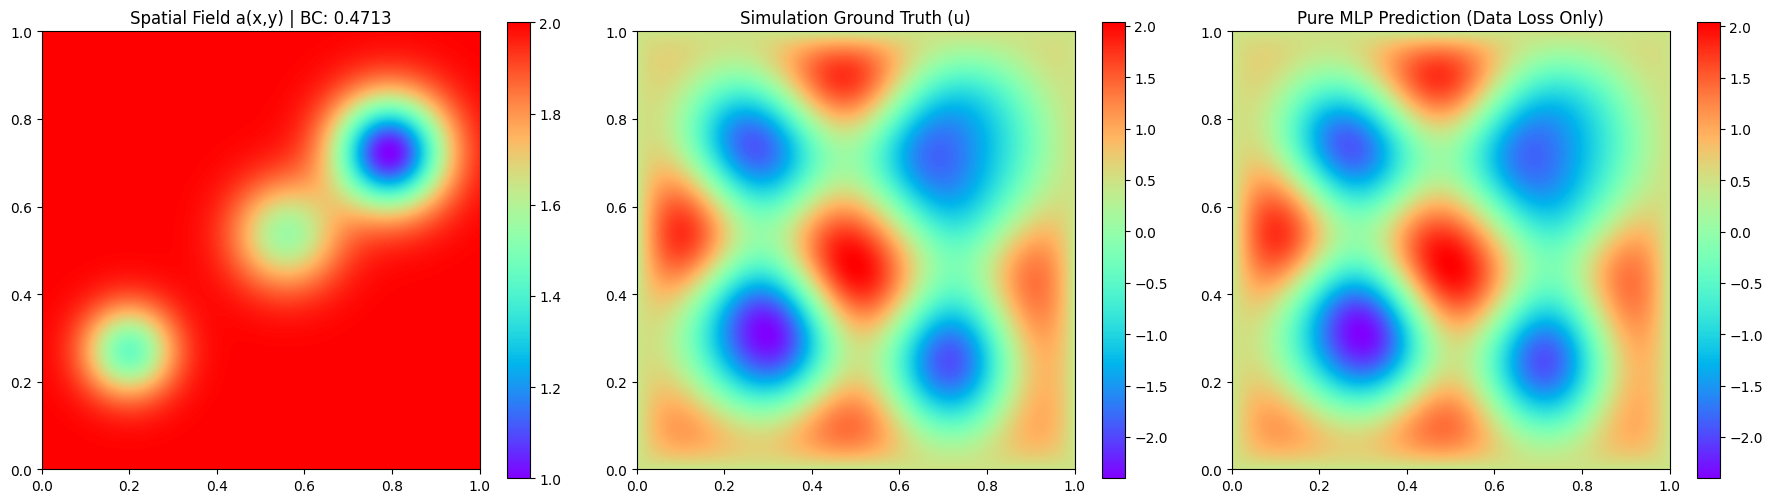

In [8]:
# Predict the full grid directly
u_pred_full = u_pred_vmap(params, x, y)

# Plotting
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('Pure MLP Prediction (Data Loss Only)')

plt.tight_layout()
plt.show()

In [9]:
import pickle
import numpy as np
from jax.tree_util import tree_map

def save_weights(params, filename="pretrained_helmholtz_mlp.pkl"):
    # Convert JAX DeviceArrays to standard NumPy arrays for safe pickling
    numpy_params = tree_map(lambda x: np.array(x), params)
    with open(filename, 'wb') as f:
        pickle.dump(numpy_params, f)
    print(f"Weights successfully saved to {filename}")

def load_weights(filename="pretrained_helmholtz_mlp.pkl"):
    with open(filename, 'rb') as f:
        numpy_params = pickle.load(f)
    # Convert back to JAX arrays
    jax_params = tree_map(lambda x: jnp.array(x), numpy_params)
    print(f"Weights successfully loaded from {filename}")
    return jax_params

# Example Usage:
save_weights(params) 
params = load_weights()

Weights successfully saved to pretrained_helmholtz_mlp.pkl
Weights successfully loaded from pretrained_helmholtz_mlp.pkl


In [ ]:
# EXTRACT FROZEN FRONT-END WEIGHTS
frozen_params = {'params': {}}
frozen_params['params']['raw_sigma'] = params['params']['raw_sigma']
for i in range(len(hidden_layers)):
    dense_name = f'Dense_{i}'
    frozen_params['params'][dense_name] = params['params'][dense_name]

# Extract and apply the learned sigma to B_matrix_base
learned_raw_sigma = params['params']['raw_sigma'][0]
learned_sigma = jax.nn.softplus(learned_raw_sigma)
print(f"Applying learned bandwidth (sigma = {learned_sigma:.4f}) to the features...")

B_matrix = B_matrix_base * learned_sigma

# DEFINE FROZEN MODEL (NO FINAL LAYER)
class FrozenFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = jnp.sin(h) 
            
        return h # Outputs shape (256,)

class FrozenConcatFeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):  
        # Grabs the learned raw_sigma directly from frozen_params
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size)(h)
            h = jnp.sin(h) 
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
        
        return combined_h

# model_frozen = FrozenFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)
model_frozen = FrozenConcatFeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)


# BUILD THE PHYSICS & BC MATRICES (SAMPLED)
omega = 5.0 * jnp.pi / 2.0
omega_sq = omega ** 2

rng = jax.random.PRNGKey(42)
total_points = x.shape[0]
spatial_batch_size = 15000 # Same batch size used in your training loop

rng, shuffle_key = jax.random.split(rng)
batch_idx = jax.random.choice(shuffle_key, total_points, shape=(spatial_batch_size,), replace=False)

x_sampled = x[batch_idx]
y_sampled = y[batch_idx]
a_sampled = a_flat[batch_idx]

@jax.jit
def compute_A_pde(x_val, y_val, a_val):
    H = model_frozen.apply(frozen_params, x_val, y_val)
    
    # Isolate the forward pass for derivatives
    def get_H(x_in, y_in):
        return model_frozen.apply(frozen_params, x_in, y_in)
        
    # Second derivatives using purely forward-mode autodiff 
    H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
    H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
    
    Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
    return -Laplacian_H - omega_sq * a_val * H

compute_A_pde_vmap = jax.jit(vmap(compute_A_pde))

print(f"Compiling and evaluating PDE matrices for {spatial_batch_size} sampled points...")
chunk_size = 1000
A_pde_chunks = []

for i in range(0, spatial_batch_size, chunk_size):
    x_chunk = x_sampled[i:i + chunk_size]
    y_chunk = y_sampled[i:i + chunk_size]
    a_chunk = a_sampled[i:i + chunk_size]
    
    A_chunk = compute_A_pde_vmap(x_chunk, y_chunk, a_chunk)
    A_pde_chunks.append(A_chunk)

A_pde = jnp.vstack(A_pde_chunks)
b_pde = jnp.zeros((spatial_batch_size, 1))

print("Compiling and evaluating BC matrices...")
A_bc = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x_bc, y_bc)
b_bc = bc_val_array.reshape(-1, 1)

print(f"Finished building matrices! A_pde shape: {A_pde.shape}, A_bc shape: {A_bc.shape}")

# HYPERPARAMETER SWEEP
lambda_bcs = [1e2, 1e3, 1e4, 1e6, 1e8, 1e10, 1e12]
tik_regs = [1e-3, 1e-4, 1e-5, 1e-6]

best_mse = float('inf')
best_params_combo = {}
best_u_pred = None

I = jnp.eye(A_pde.shape[1]) 

print("\nStarting Sweep:")
print("-" * 80)

for lmbda in lambda_bcs:
    for tik in tik_regs:
        sqrt_lambda = jnp.sqrt(lmbda)
        A = jnp.vstack([A_pde, sqrt_lambda * A_bc])
        B = jnp.vstack([b_pde, sqrt_lambda * b_bc])
        
        # Least Squares Solve
        A_T_A = A.T @ A
        A_T_B = A.T @ B
        w = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
        
        # Calculate Unscaled PDE Loss (A_pde @ w - b_pde)
        pde_residual = A_pde @ w - b_pde
        loss_pde_unscaled = jnp.mean(pde_residual ** 2)
        
        # Calculate Unscaled BC Loss (A_bc @ w - b_bc)
        bc_residual = A_bc @ w - b_bc
        loss_bc_unscaled = jnp.mean(bc_residual ** 2)
        
        # Calculate Unscaled Data MSE (Full Grid)
        H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)
        u_pred_sweep = H_full @ w
        mse = jnp.mean((u_pred_sweep - u_flat) ** 2)
        
        print(f"Lam: {lmbda:<7.1e} | Tik: {tik:<7.1e} | MSE: {mse:.2e} | PDE: {loss_pde_unscaled:.2e} | BC: {loss_bc_unscaled:.2e}")
        
        # Track the best performing combination (still based on MSE)
        if mse < best_mse:
            best_mse = mse
            best_params_combo = {'lambda': lmbda, 'tik_reg': tik, 'w': w}
            best_u_pred = u_pred_sweep

print("-" * 80)
print(f"BEST FOUND: Lambda = {best_params_combo['lambda']}, TikReg = {best_params_combo['tik_reg']}")
print(f"BEST MSE  = {best_mse:.4e}")

Applying learned bandwidth (sigma = 3.0462) to the features...
Compiling and evaluating PDE matrices for 15000 sampled points...
Compiling and evaluating BC matrices...
Finished building matrices! A_pde shape: (15000, 2048), A_bc shape: (508, 2048)

Starting Sweep:
--------------------------------------------------------------------------------
Lam: 1.0e+02 | Tik: 1.0e-03 | MSE: 6.88e-01 | PDE: 2.50e-04 | BC: 3.21e-02
Lam: 1.0e+02 | Tik: 1.0e-04 | MSE: 6.85e-01 | PDE: 2.58e-04 | BC: 3.18e-02
Lam: 1.0e+02 | Tik: 1.0e-05 | MSE: nan | PDE: nan | BC: nan
Lam: 1.0e+02 | Tik: 1.0e-06 | MSE: nan | PDE: nan | BC: nan
Lam: 1.0e+03 | Tik: 1.0e-03 | MSE: 6.83e-01 | PDE: 1.05e-02 | BC: 3.12e-02
Lam: 1.0e+03 | Tik: 1.0e-04 | MSE: 6.81e-01 | PDE: 1.09e-02 | BC: 3.11e-02
Lam: 1.0e+03 | Tik: 1.0e-05 | MSE: nan | PDE: nan | BC: nan
Lam: 1.0e+03 | Tik: 1.0e-06 | MSE: nan | PDE: nan | BC: nan
Lam: 1.0e+04 | Tik: 1.0e-03 | MSE: 6.74e-01 | PDE: 6.80e-01 | BC: 2.73e-02
Lam: 1.0e+04 | Tik: 1.0e-04 | MSE: 6.7

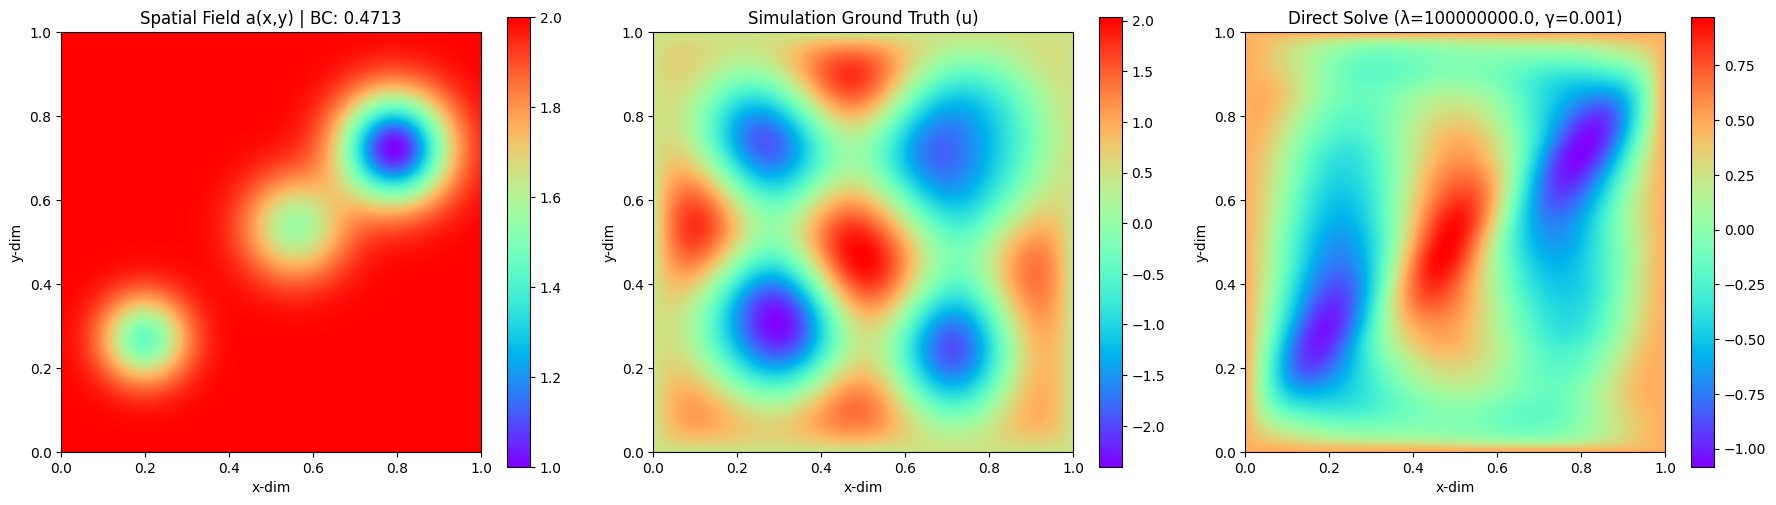

In [ ]:
# ==========================================
# E. VISUALIZE BEST SWEEP RESULT
# ==========================================
# Reshape the flattened arrays back into the 128x128 grid and transpose
a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = best_u_pred.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
title_str = f'Direct Solve (λ={best_params_combo["lambda"]}, γ={best_params_combo["tik_reg"]})'
axes[2].set_title(title_str, fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# DIFFERENTIABLE PSEUDOINVERSE LOOP
# ==========================================
params = load_weights("pretrained_helmholtz_mlp.pkl")

lmbda = 100000000.0
sqrt_lambda = jnp.sqrt(lmbda)
tik = 1e-3
omega_sq = (5.0 * jnp.pi / 2.0) ** 2

@jax.jit
def diff_pseudo_loss(params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr, x_full, y_full, u_full):
    def get_H(x_in, y_in):
        return model_frozen.apply(params, x_in, y_in) 
        
    def compute_pde_row(x_val, y_val, a_val):
        H = get_H(x_val, y_val)
        H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
        H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
        Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
        return -Laplacian_H - omega_sq * a_val * H
        
    # Build Matrices
    A_pde_diff = vmap(compute_pde_row)(x_pde, y_pde, a_pde)
    b_pde_diff = jnp.zeros((x_pde.shape[0], 1))
    
    A_bc_diff = vmap(get_H)(x_bc, y_bc)
    b_bc_diff = bc_val_arr.reshape(-1, 1)
    
    A = jnp.vstack([A_pde_diff, sqrt_lambda * A_bc_diff])
    B = jnp.vstack([b_pde_diff, sqrt_lambda * b_bc_diff])
    
    # RAW MATRIX SOLVE (No Col Norm)
    I = jnp.eye(A.shape[1])
    A_T_A = A.T @ A
    A_T_B = A.T @ B
    w_diff = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
    
    # Predict and calculate MSE
    H_full = vmap(get_H)(x_full, y_full)
    u_pred = H_full @ w_diff
    mse = jnp.mean((u_pred - u_full) ** 2)
    return mse

meta_optimizer = optax.adamw(learning_rate=1e-4) 
meta_opt_state = meta_optimizer.init(params)
loss_grad_meta_fn = jax.jit(value_and_grad(diff_pseudo_loss))

N_pde_test = 15000 
rng = jax.random.PRNGKey(99)
batch_idx = jax.random.choice(rng, x.shape[0], shape=(N_pde_test,), replace=False)

x_pde_test = x[batch_idx]
y_pde_test = y[batch_idx]
a_pde_test = a_flat[batch_idx]

print("Starting Dr. Ooi's Differentiable Pseudoinverse Loop...")
for epoch in range(40):
    loss, grads = loss_grad_meta_fn(
        params, x_pde_test, y_pde_test, a_pde_test, 
        x_bc, y_bc, bc_val_array, 
        x, y, u_flat
    )
    
    updates, meta_opt_state = meta_optimizer.update(grads, meta_opt_state, params=params)
    params = optax.apply_updates(params, updates)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Meta-MSE Loss: {loss:.4e}")

Weights successfully loaded from pretrained_helmholtz_mlp.pkl
Starting Dr. Ooi's Differentiable Pseudoinverse Loop...
Epoch 0 | Meta-MSE Loss: 6.0526e-01
Epoch 5 | Meta-MSE Loss: 6.0266e-01
Epoch 10 | Meta-MSE Loss: 6.0027e-01
Epoch 15 | Meta-MSE Loss: 5.9772e-01
Epoch 20 | Meta-MSE Loss: 5.9491e-01
Epoch 25 | Meta-MSE Loss: 5.9143e-01
Epoch 30 | Meta-MSE Loss: 5.8703e-01
Epoch 35 | Meta-MSE Loss: 5.8174e-01


Original Adam Weights Shape: (2048, 1)
Manual Multiplication MSE (Adam's Weights): 4.4325e-06
Best Pseudoinverse MSE (from Sweep):      6.0459e-01


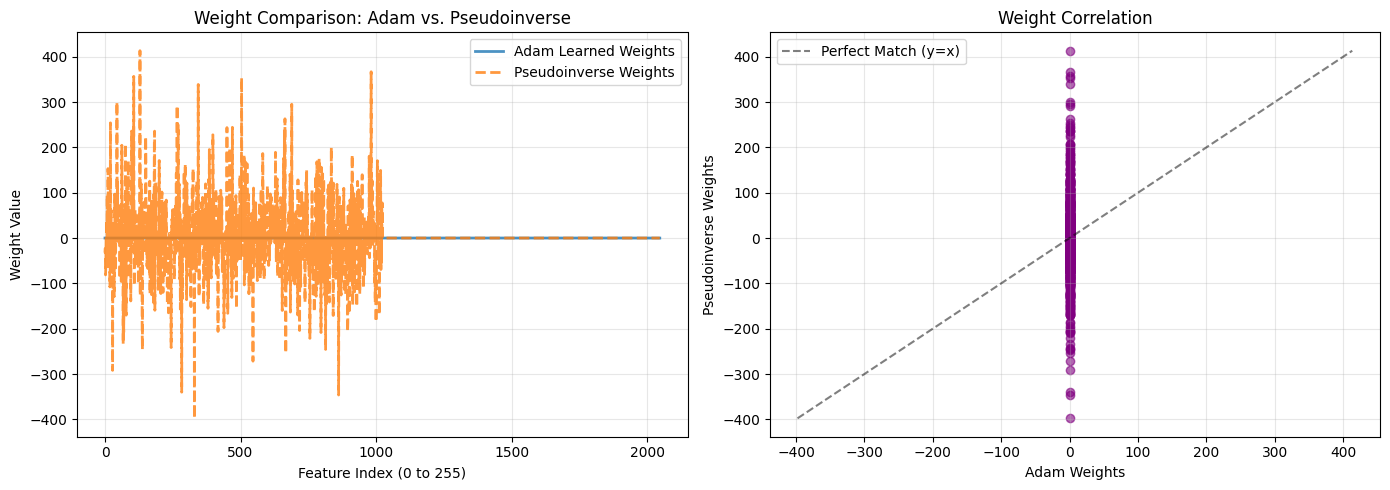

In [ ]:
w_learned = params['params']['Dense_4']['kernel']
# b_learned = params['params']['Dense_4']['bias']

print(f"Original Adam Weights Shape: {w_learned.shape}")
# print(f"Original Adam Bias: {b_learned[0]:.6f}")

H_full = vmap(lambda x_in, y_in: model_frozen.apply(frozen_params, x_in, y_in))(x, y)

# u_pred_manual = (H_full @ w_learned) + b_learned
u_pred_manual = (H_full @ w_learned)

mse_manual = jnp.mean((u_pred_manual - u_flat) ** 2)
print(f"Manual Multiplication MSE (Adam's Weights): {mse_manual:.4e}")
print(f"Best Pseudoinverse MSE (from Sweep):      {best_mse:.4e}")

# ==========================================
# VISUALIZE THE WEIGHTS (Adam vs. Pseudoinverse)
# ==========================================
w_pseudo = best_params_combo['w']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(w_learned, label='Adam Learned Weights', alpha=0.8, linewidth=2)
axes[0].plot(w_pseudo, label='Pseudoinverse Weights', alpha=0.8, linewidth=2, linestyle='dashed')
axes[0].set_title("Weight Comparison: Adam vs. Pseudoinverse", fontsize='large')
axes[0].set_xlabel("Feature Index (0 to 255)")
axes[0].set_ylabel("Weight Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(w_learned, w_pseudo, alpha=0.6, color='purple')
# Add a y=x reference line
min_val = min(jnp.min(w_learned), jnp.min(w_pseudo))
max_val = max(jnp.max(w_learned), jnp.max(w_pseudo))
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Match (y=x)')
axes[1].set_title("Weight Correlation", fontsize='large')
axes[1].set_xlabel("Adam Weights")
axes[1].set_ylabel("Pseudoinverse Weights")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

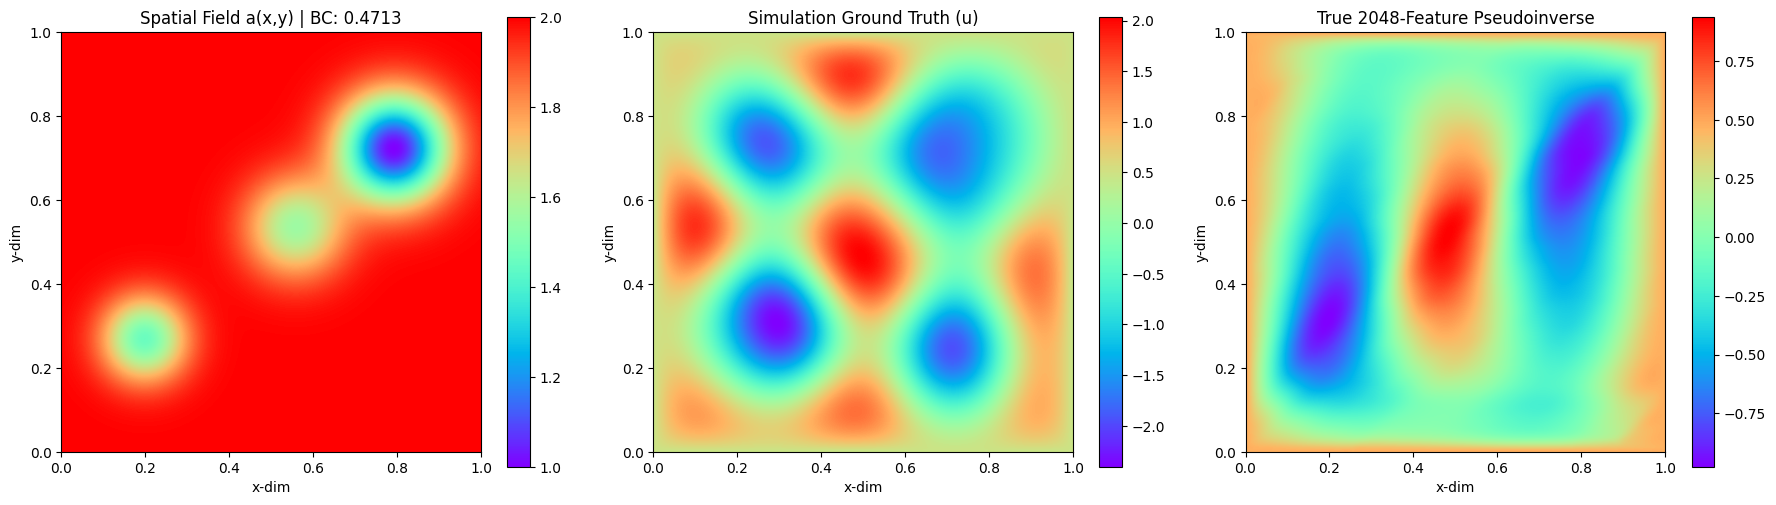

In [ ]:
# ==========================================
# VISUALIZE POST-DIAGNOSTIC RESULTS (FIXED)
# ==========================================
def get_final_w(current_params, x_pde, y_pde, a_pde, x_bc, y_bc, bc_val_arr):
    def get_H(x_in, y_in):
        return model_frozen.apply(current_params, x_in, y_in) 
        
    def compute_pde_row(x_val, y_val, a_val):
        H = get_H(x_val, y_val)
        H_xx = jax.jacfwd(jax.jacfwd(get_H, argnums=0))(x_val, y_val)
        H_yy = jax.jacfwd(jax.jacfwd(get_H, argnums=1))(x_val, y_val)
        Laplacian_H = jnp.squeeze(H_xx) + jnp.squeeze(H_yy)
        return -Laplacian_H - omega_sq * a_val * H
        
    A_pde_final = vmap(compute_pde_row)(x_pde, y_pde, a_pde)
    b_pde_final = jnp.zeros((x_pde.shape[0], 1))
    
    A_bc_final = vmap(get_H)(x_bc, y_bc)
    b_bc_final = bc_val_arr.reshape(-1, 1)
    
    A = jnp.vstack([A_pde_final, sqrt_lambda * A_bc_final])
    B = jnp.vstack([b_pde_final, sqrt_lambda * b_bc_final])
    
    I = jnp.eye(A.shape[1])
    A_T_A = A.T @ A
    A_T_B = A.T @ B
    w_scaled = jax.scipy.linalg.solve(A_T_A + tik * I, A_T_B, assume_a='pos')
    
    return w_scaled

final_w = get_final_w(params, x_pde_test, y_pde_test, a_pde_test, x_bc, y_bc, bc_val_array)

H_full_grid = vmap(lambda x_in, y_in: model_frozen.apply(params, x_in, y_in))(x, y)
u_pred_full = H_full_grid @ final_w

a_plot = a_flat.reshape(nx, ny).T
u_sim_plot = u_flat.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y) | BC: {bc_sample:.4f}', fontsize='large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('True 2048-Feature Pseudoinverse', fontsize='large')
axes[2].set_xlabel('x-dim')
axes[2].set_ylabel('y-dim')

plt.tight_layout()
plt.show()